# Laborator 2 - Formula lui Bayes

Investigăm o boală $B$ care afectează doar un procent din populaţie: $P(B) = 0.01$.
Avem un test de diagnosticare cu următoarele caracteristici:

- **Sensibilitate:** $P(\text{Test}=\text{Pozitiv} \mid B) = 0.95$
- **Specificitate:** $P(\text{Test}=\text{Negativ} \mid \neg B) = 0.90$

**Cerinţe:**
- a) Dacă o persoană este testată şi rezultatul este pozitiv, care este probabilitatea să fie efectiv bolnavă? Cum explicăm rezultatul?
- b) Modelaţi în Python probabilitatea de mai sus şi comparaţi cu cea teoretică.
- c) Care ar trebui să fie specificitatea minimă pentru ca probabilitatea de mai sus să ajungă la 50%?

## a) Rezolvare teoretică

Notăm $T^+$ = "testul este pozitiv". Din enunţ avem:

$$P(B) = 0.01, \qquad P(\neg B) = 0.99$$
$$P(T^+ \mid B) = 0.95, \qquad P(T^- \mid \neg B) = 0.90 \;\Rightarrow\; P(T^+ \mid \neg B) = 1 - 0.90 = 0.10$$

Vrem $P(B \mid T^+)$. Folosim **formula lui Bayes**:

$$P(B \mid T^+) = \frac{P(T^+ \mid B)\, P(B)}{P(T^+)}$$

iar numitorul îl calculăm cu **formula probabilităţii totale**:

$$P(T^+) = P(T^+ \mid B)\,P(B) + P(T^+ \mid \neg B)\,P(\neg B) = 0.95 \cdot 0.01 + 0.10 \cdot 0.99 = 0.0095 + 0.099 = 0.1085$$

Deci:

$$P(B \mid T^+) = \frac{0.0095}{0.1085} \approx 0.0876 \approx 8.76\%$$

### Cum explicăm rezultatul?

Deşi testul pare bun (95% sensibilitate, 90% specificitate), un rezultat pozitiv înseamnă doar ~8.8% şanse să fii bolnav. Motivul este că boala este **rară** ($1\%$).

Imaginăm 10000 de oameni:
- 100 sunt bolnavi, iar testul îi depistează pe $0.95 \cdot 100 = 95$ dintre ei (adevăraţi pozitivi);
- 9900 sunt sănătoşi, iar testul dă greşit pozitiv pentru $0.10 \cdot 9900 = 990$ dintre ei (fals pozitivi).

Total pozitivi: $95 + 990 = 1085$, iar doar $95$ sunt cu adevărat bolnavi: $95 / 1085 \approx 8.76\%$.

Falşii pozitivi (990) sunt mult mai mulţi decât adevăraţii pozitivi (95), pentru că 10% eroare aplicată unei populaţii mari de sănătoşi dă mulţi oameni.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(12)

# Parametrii din enunt
p_B = 0.01          # P(B)
sens = 0.95         # P(Test+ | B)
spec = 0.90         # P(Test- | nonB)

# Calcul teoretic cu formula lui Bayes
p_pos = sens * p_B + (1 - spec) * (1 - p_B)   # P(Test+), probabilitatea totala
p_B_dat_pos = sens * p_B / p_pos              # P(B | Test+)

print(f"P(Test+)   = {p_pos:.4f}")
print(f"P(B|Test+) = {p_B_dat_pos:.4f}  (~ {100 * p_B_dat_pos:.2f}%)")

Matplotlib is building the font cache; this may take a moment.


P(Test+)   = 0.1085
P(B|Test+) = 0.0876  (~ 8.76%)


## b) Simulare în Python

Simulăm o populaţie mare de persoane:
1. pentru fiecare persoană generăm dacă este bolnavă (cu probabilitatea $P(B) = 0.01$);
2. generăm rezultatul testului: dacă e bolnavă, testul e pozitiv cu probabilitatea $0.95$; dacă e sănătoasă, e pozitiv cu probabilitatea $1 - 0.90 = 0.10$;
3. dintre persoanele cu test pozitiv, calculăm ce proporţie sunt cu adevărat bolnave. Aceasta estimează $P(B \mid T^+)$.

In [2]:
def simuleaza(n, p_B, sens, spec):
    # True = bolnav, False = sanatos
    bolnav = np.random.rand(n) < p_B

    # probabilitatea ca testul sa fie pozitiv depinde de starea persoanei
    p_test_pozitiv = np.where(bolnav, sens, 1 - spec)
    test_pozitiv = np.random.rand(n) < p_test_pozitiv

    # dintre cei cu test pozitiv, ce proportie sunt bolnavi?
    return bolnav[test_pozitiv].mean()

n = 1_000_000
estimare = simuleaza(n, p_B, sens, spec)

print(f"Estimare prin simulare ({n} persoane): {estimare:.4f}")
print(f"Valoare teoretica:                     {p_B_dat_pos:.4f}")
print(f"Diferenta absoluta:                    {abs(estimare - p_B_dat_pos):.5f}")

Estimare prin simulare (1000000 persoane): 0.0877
Valoare teoretica:                     0.0876
Diferenta absoluta:                    0.00018


Estimarea din simulare este foarte apropiată de valoarea teoretică, deci rezultatul din punctul a) este confirmat. Mai jos arătăm cum converge estimarea când creştem numărul de persoane simulate.

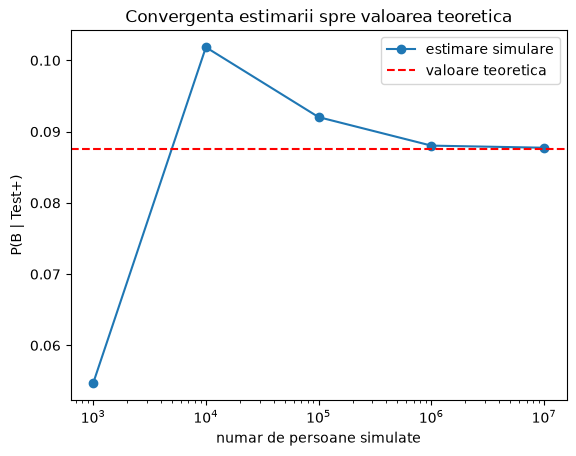

In [3]:
dimensiuni = [10**k for k in range(3, 8)]   # 1e3 ... 1e7
estimari = [simuleaza(m, p_B, sens, spec) for m in dimensiuni]

plt.semilogx(dimensiuni, estimari, "o-", label="estimare simulare")
plt.axhline(p_B_dat_pos, color="red", linestyle="--", label="valoare teoretica")
plt.xlabel("numar de persoane simulate")
plt.ylabel("P(B | Test+)")
plt.title("Convergenta estimarii spre valoarea teoretica")
plt.legend()
plt.show()

## c) Specificitatea minimă pentru $P(B \mid T^+) = 50\%$

Notăm specificitatea cu $s = P(T^- \mid \neg B)$, deci $P(T^+ \mid \neg B) = 1 - s$. Impunem:

$$P(B \mid T^+) = \frac{0.95 \cdot 0.01}{0.95 \cdot 0.01 + (1 - s)\cdot 0.99} = 0.5$$

Egalitatea cu $\tfrac12$ înseamnă că numărătorul este egal cu restul numitorului, adică adevăraţii pozitivi sunt cât falşii pozitivi:

$$0.95 \cdot 0.01 = (1 - s) \cdot 0.99 \;\Rightarrow\; 1 - s = \frac{0.0095}{0.99} \approx 0.009596$$

$$\boxed{s \approx 0.9904 = 99.04\%}$$

Deci specificitatea ar trebui să crească de la 90% la cel puţin **~99.04%**. Pentru o boală rară, ce contează cel mai mult este rata de fals pozitivi.

Specificitate minima: 0.9904  (~ 99.04%)
Verificare P(B|Test+) = 0.5000


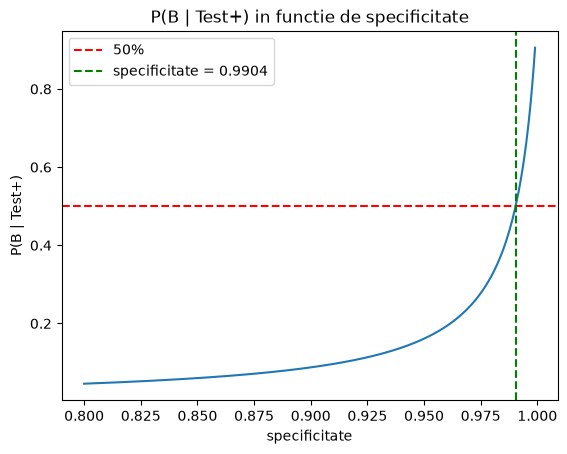

In [4]:
# Valoarea exacta a specificitatii pentru P(B|Test+) = 0.5
spec_min = 1 - (sens * p_B) / (0.99)
print(f"Specificitate minima: {spec_min:.4f}  (~ {100 * spec_min:.2f}%)")

# Verificare: P(B|Test+) cu aceasta specificitate
verif = sens * p_B / (sens * p_B + (1 - spec_min) * (1 - p_B))
print(f"Verificare P(B|Test+) = {verif:.4f}")

# Cum depinde P(B|Test+) de specificitate
specificitati = np.linspace(0.80, 0.999, 300)
post = sens * p_B / (sens * p_B + (1 - specificitati) * (1 - p_B))

plt.plot(specificitati, post)
plt.axhline(0.5, color="red", linestyle="--", label="50%")
plt.axvline(spec_min, color="green", linestyle="--", label=f"specificitate = {spec_min:.4f}")
plt.xlabel("specificitate")
plt.ylabel("P(B | Test+)")
plt.title("P(B | Test+) in functie de specificitate")
plt.legend()
plt.show()

In [5]:
# Verificare prin simulare cu specificitatea gasita
est_c = simuleaza(5_000_000, p_B, sens, spec_min)
print(f"Estimare prin simulare cu specificitate {spec_min:.4f}: {est_c:.4f}  (asteptat ~ 0.5)")

Estimare prin simulare cu specificitate 0.9904: 0.4987  (asteptat ~ 0.5)
